# Experiment: MESS with Varying Dimensions (Gaussian Process Regression)

This notebook compares ESS, MESS uniform, and MESS with different distance metrics across varying problem dimensions (D = [1, 5, 10]) on GP regression problems. We track effective sample size (ESS), mean squared jumping distance (MSJD), number of intervals (shrinking steps), and computation time.

In [1]:
import sys
import os
import time

# Get absolute path to src directory (go up from notebooks to repo root)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
sys.path.insert(0, src_path)

print(f"Repo root: {repo_root}")
print(f"Added to path: {src_path}")

import numpy as np
import matplotlib.pyplot as plt
from mess.data.gp_regression import generate_gp_regression_data
from mess.problems.gp_regression import GaussianProcessRegression
from mess.algorithms.ess import ess_step
from mess.algorithms.mess import mess_step
from mess.algorithms.effective_sample_size import (
    estimate_effective_sample_size,
    compute_mean_squared_jumping_distance,
    compute_normalized_jumping_distance
)

Repo root: /Users/guillers/Documents/GitHub/mess
Added to path: /Users/guillers/Documents/GitHub/mess/src


## Experiment Setup

In [2]:
# Problem parameters
D_values = [1, 5, 10]  # Different dimensions to test
num_data = 200
length_scale = 1.0
noise_variance = 0.09

# Sampler parameters
n_iters = 1000  # Number of MCMC iterations
burn_in = 500
seed = 42

# MESS M values to test
M_values = [1, 2, 10, 20]
M_values_filtered = [M for M in M_values if M <= 100]  # For angular/euclidean

print(f"Experiment setup:")
print(f"  Dimensions: {D_values}")
print(f"  num_data: {num_data}")
print(f"  n_iters: {n_iters}")
print(f"  M values: {M_values}")

Experiment setup:
  Dimensions: [1, 5, 10]
  num_data: 200
  n_iters: 1000
  M values: [1, 2, 10, 20]


## Run Experiments for All Dimensions

For each dimension D, we run MESS with uniform, angular, and euclidean variants.

In [3]:
# Store results for all dimensions
results_by_dim = {}

for D in D_values:
    print(f"\n{'='*80}")
    print(f"Running experiments for D = {D}")
    print(f"{'='*80}")
    
    # Generate data
    data = generate_gp_regression_data(
        num_data=num_data,
        num_dims=D,
        length_scale=length_scale,
        noise_variance=noise_variance,
        seed=seed,
    )
    
    X = data["X"]
    y = data["y"]
    x0 = data["f_init"]
    
    # Create problem
    problem = GaussianProcessRegression(
        X=X,
        y=y,
        length_scale=length_scale,
        noise_variance=noise_variance,
    )
    
    print(f"Data generated: X={X.shape}, y={y.shape}")
    
    # Initialize results dictionary for this dimension
    dim_results = {
        'D': D,
        'uniform': {'intervals': {}, 'chains': {}, 'times': [], 'statistics': {}},
        'angular': {'intervals': {}, 'chains': {}, 'times': [], 'statistics': {}},
        'euclidean': {'intervals': {}, 'chains': {}, 'times': [], 'statistics': {}},
        'ess': {'uniform': {}, 'angular': {}, 'euclidean': {}},
        'msjd': {'uniform': {}, 'angular': {}, 'euclidean': {}},
    }
    
    # Run MESS Uniform
    print(f"\nRunning MESS Uniform...")
    for M in M_values:
        print(f"  M = {M}")
        rng = np.random.default_rng(seed)
        chain = np.zeros((n_iters, num_data))
        intervals = np.zeros(n_iters, dtype=int)
        x = x0.copy()
        
        t0 = time.time()
        for t in range(n_iters):
            x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=False)
            chain[t] = x
            intervals[t] = nr_intervals
        elapsed = time.time() - t0
        
        dim_results['uniform']['chains'][M] = chain
        dim_results['uniform']['intervals'][M] = intervals
        dim_results['uniform']['times'].append(elapsed)
        
        # Compute statistics
        intervals_post = intervals[burn_in:]
        dim_results['uniform']['statistics'][M] = {
            'mean_intervals': np.mean(intervals_post),
            'std_intervals': np.std(intervals_post),
            'median_intervals': np.median(intervals_post),
        }
        
        print(f"    Time: {elapsed:.2f}s, Mean intervals: {np.mean(intervals_post):.4f}")
    
    # Run MESS Angular
    print(f"\nRunning MESS Angular...")
    for M in M_values_filtered:
        print(f"  M = {M}")
        rng = np.random.default_rng(seed)
        chain = np.zeros((n_iters + 1, num_data))
        chain[0] = x0.copy()
        intervals = np.zeros(n_iters, dtype=int)
        x = x0.copy()
        
        t0 = time.time()
        for t in range(n_iters):
            x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=True,
                                           distance_metric='angular', lam=0.05)
            chain[t + 1] = x
            intervals[t] = nr_intervals
        elapsed = time.time() - t0
        
        dim_results['angular']['chains'][M] = chain
        dim_results['angular']['intervals'][M] = intervals
        dim_results['angular']['times'].append(elapsed)
        
        # Compute statistics
        intervals_post = intervals[burn_in + 1:]
        dim_results['angular']['statistics'][M] = {
            'mean_intervals': np.mean(intervals_post),
            'std_intervals': np.std(intervals_post),
            'median_intervals': np.median(intervals_post),
        }
        
        print(f"    Time: {elapsed:.2f}s, Mean intervals: {np.mean(intervals_post):.4f}")
    
    # Run MESS Euclidean
    print(f"\nRunning MESS Euclidean...")
    for M in M_values_filtered:
        print(f"  M = {M}")
        rng = np.random.default_rng(seed)
        chain = np.zeros((n_iters + 1, num_data))
        chain[0] = x0.copy()
        intervals = np.zeros(n_iters, dtype=int)
        x = x0.copy()
        
        t0 = time.time()
        for t in range(n_iters):
            x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=True,
                                           distance_metric='euclidean', lam=0.05)
            chain[t + 1] = x
            intervals[t] = nr_intervals
        elapsed = time.time() - t0
        
        dim_results['euclidean']['chains'][M] = chain
        dim_results['euclidean']['intervals'][M] = intervals
        dim_results['euclidean']['times'].append(elapsed)
        
        # Compute statistics
        intervals_post = intervals[burn_in + 1:]
        dim_results['euclidean']['statistics'][M] = {
            'mean_intervals': np.mean(intervals_post),
            'std_intervals': np.std(intervals_post),
            'median_intervals': np.median(intervals_post),
        }
        
        print(f"    Time: {elapsed:.2f}s, Mean intervals: {np.mean(intervals_post):.4f}")
    
    results_by_dim[D] = dim_results

print(f"\n{'='*80}")
print("All experiments completed!")
print(f"{'='*80}")


Running experiments for D = 1
Data generated: X=(1, 200), y=(200,)

Running MESS Uniform...
  M = 1
    Time: 0.12s, Mean intervals: 6.5920
  M = 2
    Time: 0.11s, Mean intervals: 3.6220
  M = 10
    Time: 0.08s, Mean intervals: 1.1500
  M = 20
    Time: 0.09s, Mean intervals: 0.7740

Running MESS Angular...
  M = 1
    Time: 3.62s, Mean intervals: 6.8938
  M = 2
    Time: 3.25s, Mean intervals: 3.7776
  M = 10
    Time: 3.31s, Mean intervals: 1.2365
  M = 20
    Time: 3.66s, Mean intervals: 0.7695

Running MESS Euclidean...
  M = 1
    Time: 3.31s, Mean intervals: 6.8938
  M = 2
    Time: 3.14s, Mean intervals: 3.7776
  M = 10
    Time: 3.33s, Mean intervals: 1.1784
  M = 20
    Time: 3.67s, Mean intervals: 0.8016

Running experiments for D = 5
Data generated: X=(5, 200), y=(200,)

Running MESS Uniform...
  M = 1
    Time: 0.12s, Mean intervals: 6.9040
  M = 2
    Time: 0.10s, Mean intervals: 3.9700
  M = 10
    Time: 0.08s, Mean intervals: 1.2880
  M = 20
    Time: 0.09s, Mean inte

## Compute ESS and MSJD for All Dimensions

In [4]:
max_lag = 1500

for D in D_values:
    print(f"\nComputing ESS and MSJD for D = {D}")
    dim_results = results_by_dim[D]
    
    # Compute ESS for Uniform
    for M in M_values:
        chain = dim_results['uniform']['chains'][M][burn_in:, :]
        ess_values = estimate_effective_sample_size(chain, max_lag=max_lag)
        msjd_values = compute_mean_squared_jumping_distance(chain)
        
        dim_results['ess']['uniform'][M] = ess_values
        dim_results['msjd']['uniform'][M] = msjd_values
    
    # Compute ESS for Angular
    for M in M_values_filtered:
        chain = dim_results['angular']['chains'][M][burn_in+1:, :]
        ess_values = estimate_effective_sample_size(chain, max_lag=max_lag)
        msjd_values = compute_mean_squared_jumping_distance(chain)
        
        dim_results['ess']['angular'][M] = ess_values
        dim_results['msjd']['angular'][M] = msjd_values
    
    # Compute ESS for Euclidean
    for M in M_values_filtered:
        chain = dim_results['euclidean']['chains'][M][burn_in+1:, :]
        ess_values = estimate_effective_sample_size(chain, max_lag=max_lag)
        msjd_values = compute_mean_squared_jumping_distance(chain)
        
        dim_results['ess']['euclidean'][M] = ess_values
        dim_results['msjd']['euclidean'][M] = msjd_values

print("\nESS and MSJD computation completed!")


Computing ESS and MSJD for D = 1
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.

/Users/guillers/Documents/GitHub/mess/src/mess/algorithms/effective_sample_size.py:93: RuntimeWarning: invalid value encountered in scalar divide
  acf[lag] = np.sum(x[lag:] * x[:-lag]) / ((N - lag) * variance)



Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.

Computing ESS and MSJD for D = 5
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.

Computing ESS and MSJD for D = 10
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for e

## Figure 1: ESS and MSJD Boxplots by Dimension (3x2 Grid)

Left column: ESS distributions, Right column: MSJD distributions. Each row corresponds to a different dimension D.

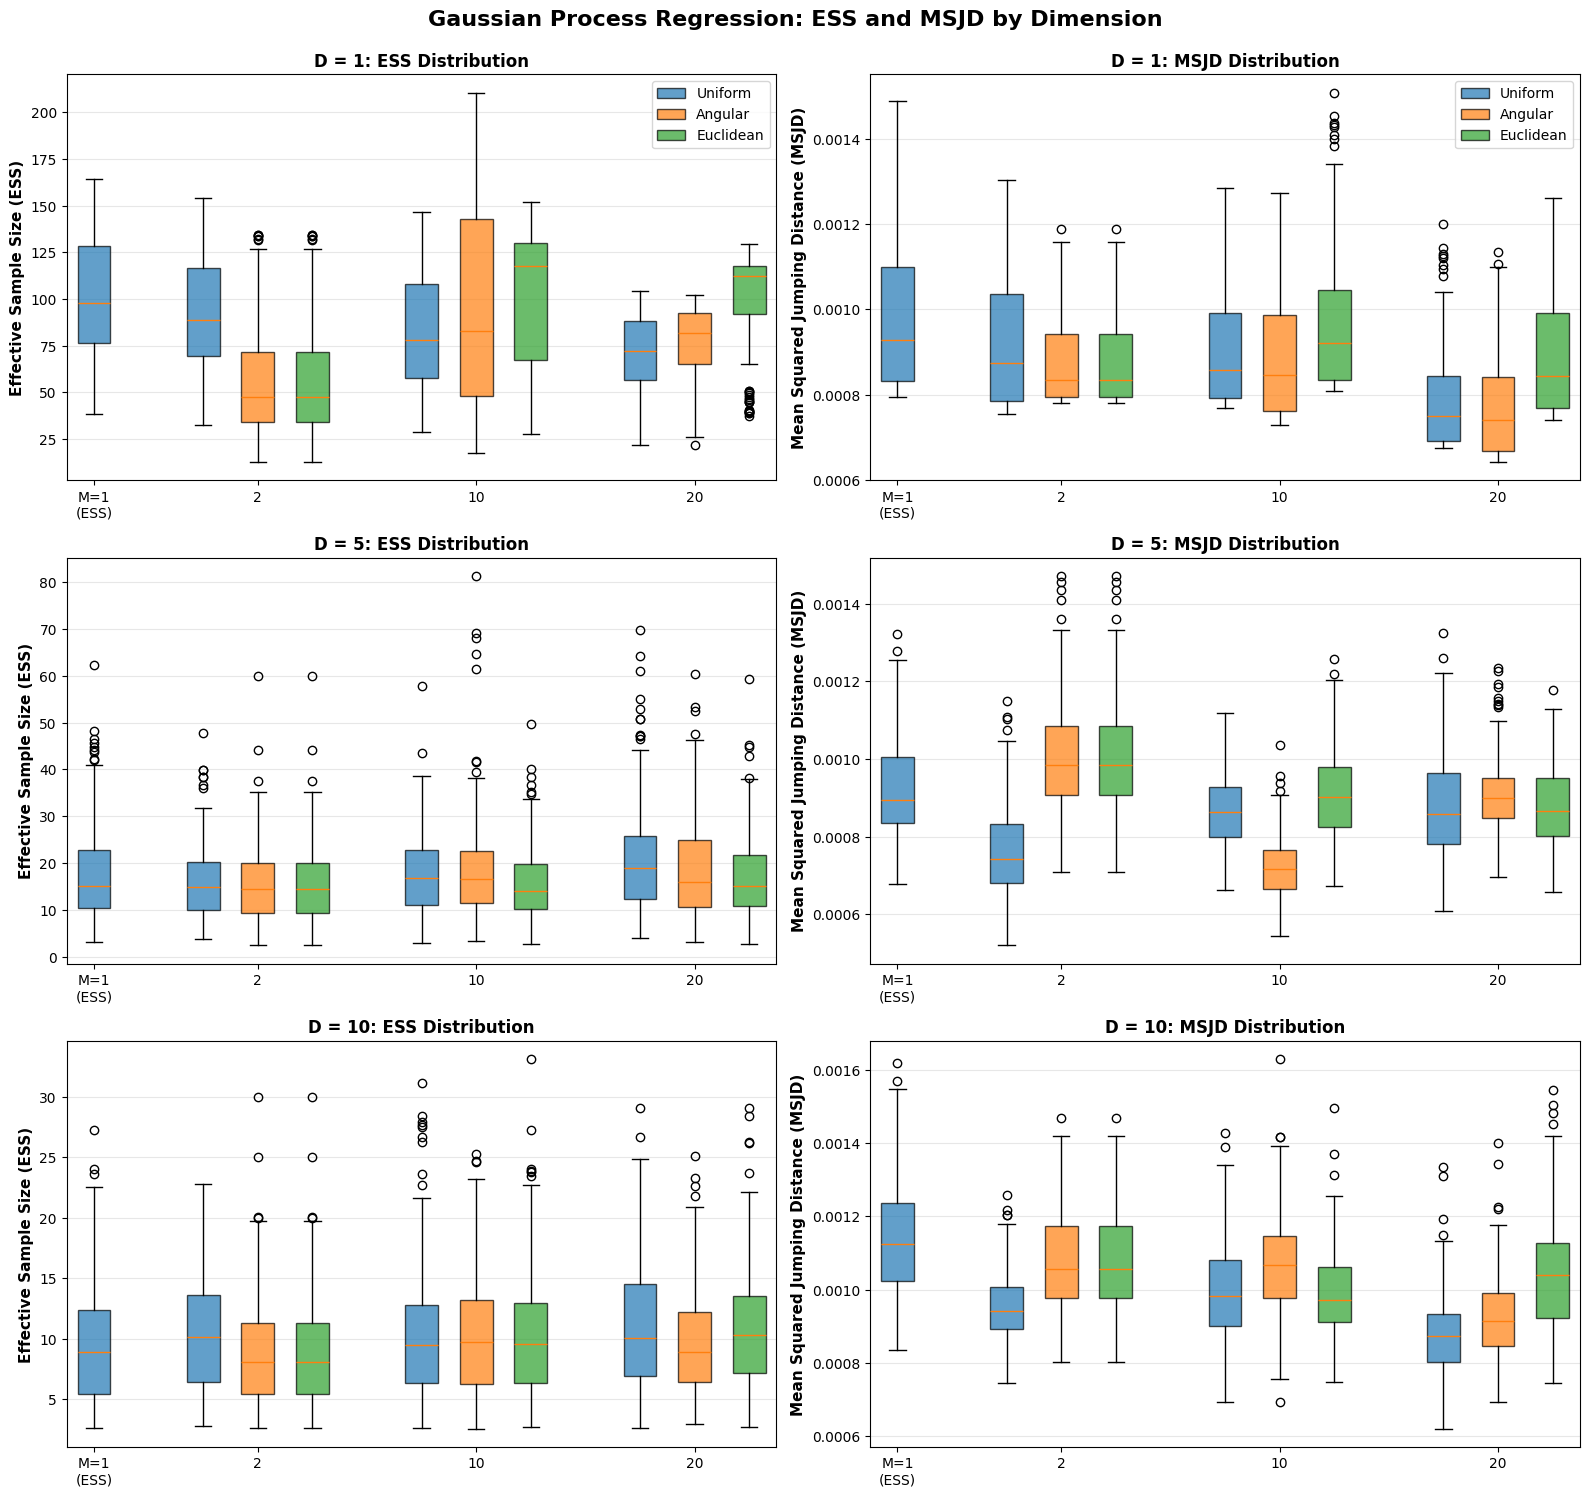

In [15]:
# Create 3x2 figure: ESS (left) and MSJD (right) for each D
fig, axes = plt.subplots(len(D_values), 2, figsize=(16, 15))
fig.suptitle('Gaussian Process Regression: ESS and MSJD by Dimension', fontsize=16, fontweight='bold', y=0.995)

for dim_idx, D in enumerate(D_values):
    dim_results = results_by_dim[D]
    
    # Prepare boxplot data
    uniform_ess_box = []
    angular_ess_box = []
    euclidean_ess_box = []
    uniform_msjd_box = []
    angular_msjd_box = []
    euclidean_msjd_box = []
    M_box = []
    
    for M in M_values:
        uniform_ess_box.append(dim_results['ess']['uniform'][M])
        uniform_msjd_box.append(dim_results['msjd']['uniform'][M])
        M_box.append(M)
        
        if M > 1 and M in M_values_filtered:
            angular_ess_box.append(dim_results['ess']['angular'][M])
            euclidean_ess_box.append(dim_results['ess']['euclidean'][M])
            angular_msjd_box.append(dim_results['msjd']['angular'][M])
            euclidean_msjd_box.append(dim_results['msjd']['euclidean'][M])
    
    # ===== ESS BOXPLOT (LEFT) =====
    ax = axes[dim_idx, 0]
    
    # Positions
    positions_uniform = []
    positions_angular = []
    positions_euclidean = []
    pos_counter = 0
    
    for i, M in enumerate(M_box):
        positions_uniform.append(pos_counter)
        pos_counter += 1
        
        if M > 1:
            positions_angular.append(pos_counter)
            pos_counter += 1
            positions_euclidean.append(pos_counter)
            pos_counter += 1
        
        pos_counter += 1
    
    # Create boxplots
    bp1 = ax.boxplot(uniform_ess_box, positions=positions_uniform, widths=0.6,
                      patch_artist=True, label='Uniform')
    bp2 = ax.boxplot(angular_ess_box, positions=positions_angular, widths=0.6,
                      patch_artist=True, label='Angular')
    bp3 = ax.boxplot(euclidean_ess_box, positions=positions_euclidean, widths=0.6,
                      patch_artist=True, label='Euclidean')
    
    # Color boxes
    for patch in bp1['boxes']:
        patch.set_facecolor('#1f77b4')
        patch.set_alpha(0.7)
    for patch in bp2['boxes']:
        patch.set_facecolor('#ff7f0e')
        patch.set_alpha(0.7)
    for patch in bp3['boxes']:
        patch.set_facecolor('#2ca02c')
        patch.set_alpha(0.7)
    
    # X-axis labels
    x_ticks = []
    x_labels = []
    for i, M in enumerate(M_box):
        if M == 1:
            x_ticks.append(positions_uniform[i])
            x_labels.append(f"M={int(M)}\n(ESS)")
        else:
            j = len([m for m in M_box[:i+1] if m > 1]) - 1
            avg_pos = (positions_uniform[i] + positions_angular[j] + positions_euclidean[j]) / 3
            x_ticks.append(avg_pos)
            x_labels.append(str(int(M)))
    
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('Effective Sample Size (ESS)', fontsize=11, fontweight='bold')
    ax.set_title(f'D = {D}: ESS Distribution', fontsize=12, fontweight='bold')
    if dim_idx == 0:
        ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, axis='y')
    
    # ===== MSJD BOXPLOT (RIGHT) =====
    ax = axes[dim_idx, 1]
    
    # Positions
    positions_uniform_m = []
    positions_angular_m = []
    positions_euclidean_m = []
    pos_counter = 0
    
    for i, M in enumerate(M_box):
        positions_uniform_m.append(pos_counter)
        pos_counter += 1
        
        if M > 1:
            positions_angular_m.append(pos_counter)
            pos_counter += 1
            positions_euclidean_m.append(pos_counter)
            pos_counter += 1
        
        pos_counter += 1
    
    # Create boxplots
    bp1 = ax.boxplot(uniform_msjd_box, positions=positions_uniform_m, widths=0.6,
                      patch_artist=True, label='Uniform')
    bp2 = ax.boxplot(angular_msjd_box, positions=positions_angular_m, widths=0.6,
                      patch_artist=True, label='Angular')
    bp3 = ax.boxplot(euclidean_msjd_box, positions=positions_euclidean_m, widths=0.6,
                      patch_artist=True, label='Euclidean')
    
    # Color boxes
    for patch in bp1['boxes']:
        patch.set_facecolor('#1f77b4')
        patch.set_alpha(0.7)
    for patch in bp2['boxes']:
        patch.set_facecolor('#ff7f0e')
        patch.set_alpha(0.7)
    for patch in bp3['boxes']:
        patch.set_facecolor('#2ca02c')
        patch.set_alpha(0.7)
    
    # X-axis labels
    x_ticks = []
    x_labels = []
    for i, M in enumerate(M_box):
        if M == 1:
            x_ticks.append(positions_uniform_m[i])
            x_labels.append(f"M={int(M)}\n(ESS)")
        else:
            j = len([m for m in M_box[:i+1] if m > 1]) - 1
            avg_pos = (positions_uniform_m[i] + positions_angular_m[j] + positions_euclidean_m[j]) / 3
            x_ticks.append(avg_pos)
            x_labels.append(str(int(M)))
    
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('Mean Squared Jumping Distance (MSJD)', fontsize=11, fontweight='bold')
    ax.set_title(f'D = {D}: MSJD Distribution', fontsize=12, fontweight='bold')
    if dim_idx == 0:
        ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [16]:
# save the fig
fig.savefig('gp_regression_ess_msjd_boxplots.png', dpi=600)

## Figure 2: Shrinking Steps and Computation Time by Dimension (3x2 Grid)

Left column: Number of shrinking steps, Right column: Computation time. Each row corresponds to a different dimension D.

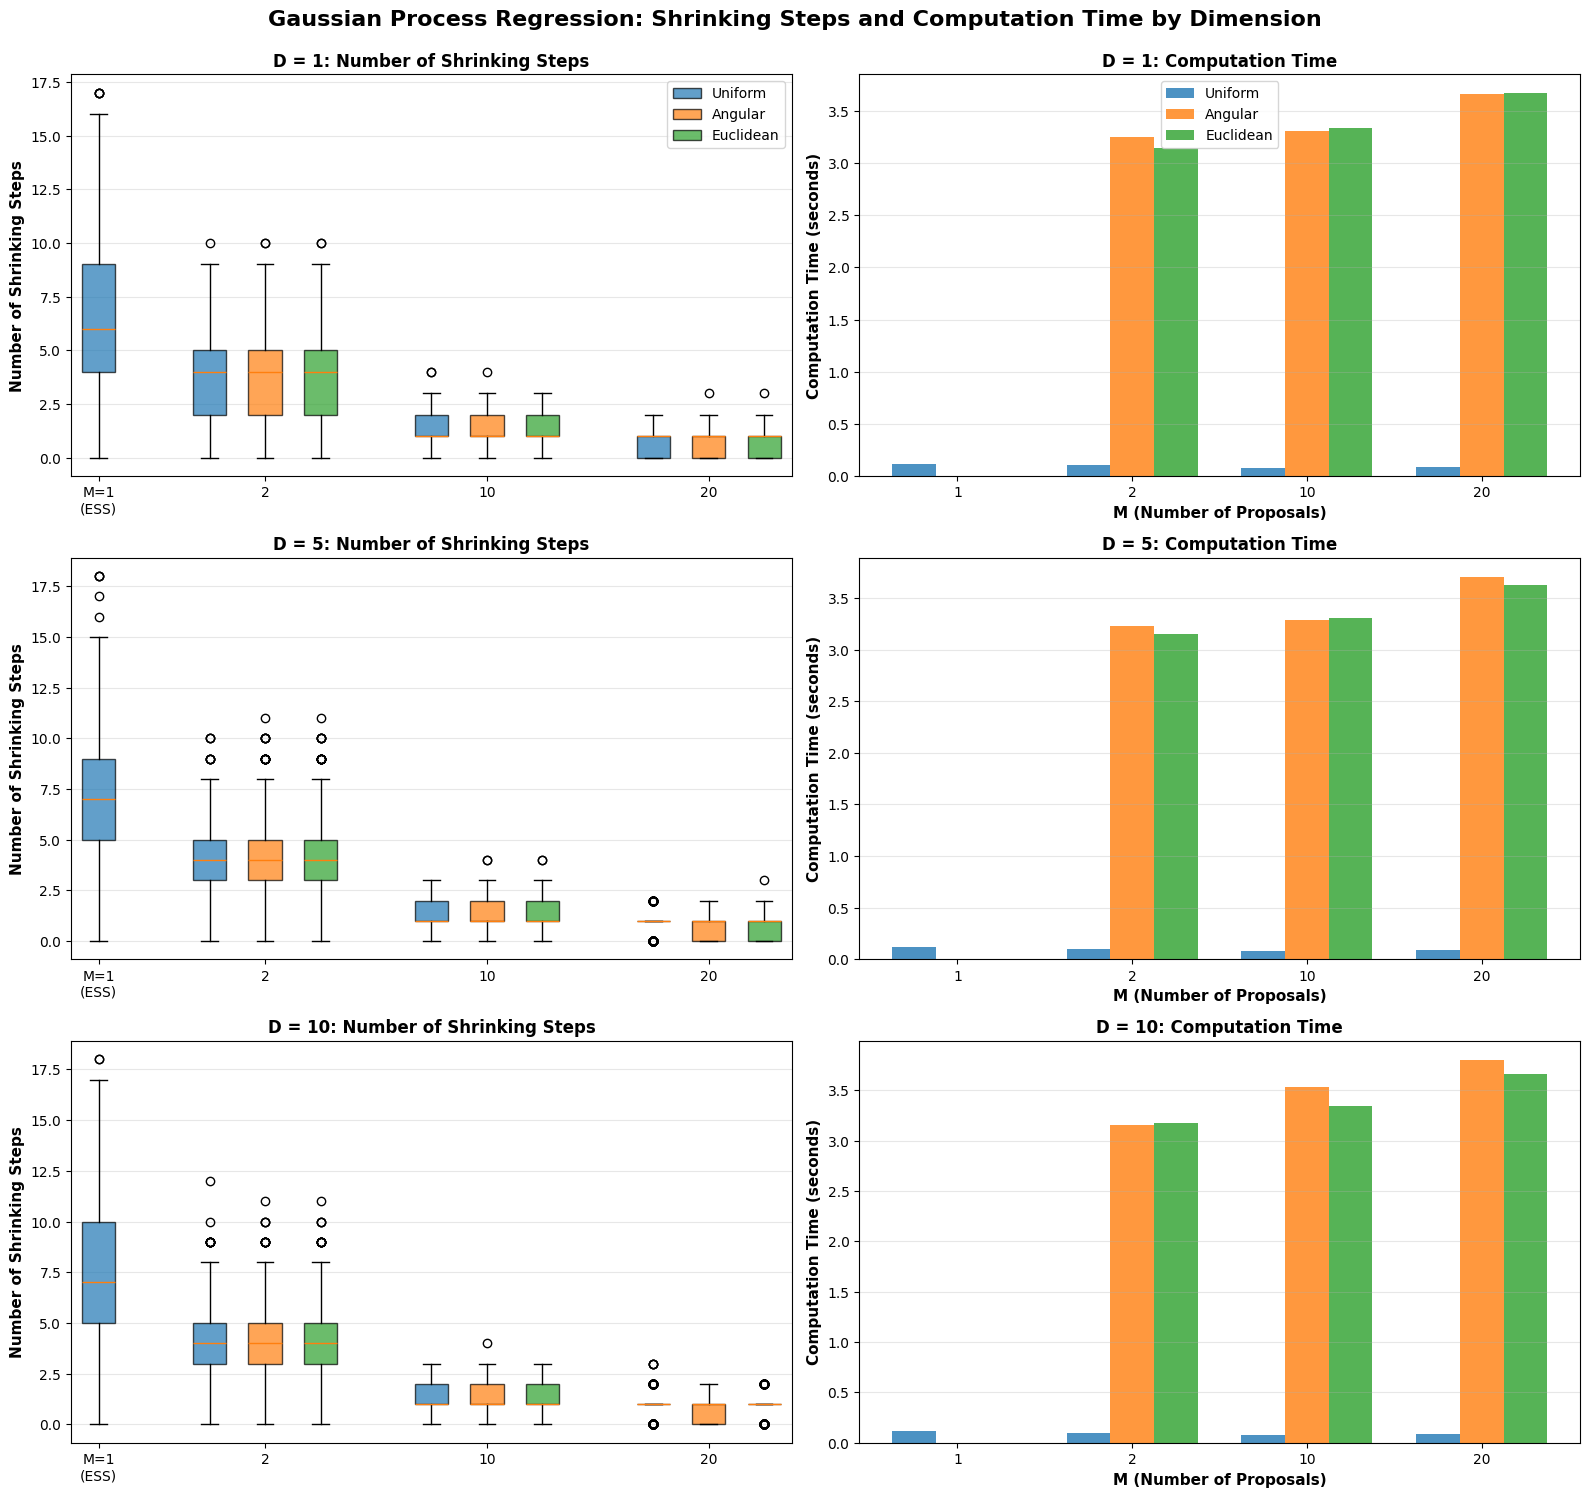

In [13]:
# Create 3x2 figure: Intervals and Time for each D
fig, axes = plt.subplots(len(D_values), 2, figsize=(16, 15))
fig.suptitle('Gaussian Process Regression: Shrinking Steps and Computation Time by Dimension', fontsize=16, fontweight='bold', y=0.995)

for dim_idx, D in enumerate(D_values):
    dim_results = results_by_dim[D]
    
    # Prepare data
    uniform_intervals_box = []
    angular_intervals_box = []
    euclidean_intervals_box = []
    M_box = []
    
    for M in M_values:
        intervals = dim_results['uniform']['intervals'][M][burn_in:]
        uniform_intervals_box.append(intervals)
        M_box.append(M)
        
        if M > 1 and M in M_values_filtered:  # FIXED: Only add for M > 1
            intervals_ang = dim_results['angular']['intervals'][M][burn_in+1:]
            intervals_euc = dim_results['euclidean']['intervals'][M][burn_in+1:]
            angular_intervals_box.append(intervals_ang)
            euclidean_intervals_box.append(intervals_euc)
    
    # ===== SHRINKING STEPS BOXPLOT (LEFT) =====
    ax = axes[dim_idx, 0]
    
    # Positions
    positions_uniform = []
    positions_angular = []
    positions_euclidean = []
    pos_counter = 0
    
    for i, M in enumerate(M_box):
        positions_uniform.append(pos_counter)
        pos_counter += 1
        
        if M > 1:
            positions_angular.append(pos_counter)
            pos_counter += 1
            positions_euclidean.append(pos_counter)
            pos_counter += 1
        
        pos_counter += 1
    
    # Create boxplots
    bp1 = ax.boxplot(uniform_intervals_box, positions=positions_uniform, widths=0.6,
                      patch_artist=True, label='Uniform')
    bp2 = ax.boxplot(angular_intervals_box, positions=positions_angular, widths=0.6,
                      patch_artist=True, label='Angular')
    bp3 = ax.boxplot(euclidean_intervals_box, positions=positions_euclidean, widths=0.6,
                      patch_artist=True, label='Euclidean')
    
    # Color boxes
    for patch in bp1['boxes']:
        patch.set_facecolor('#1f77b4')
        patch.set_alpha(0.7)
    for patch in bp2['boxes']:
        patch.set_facecolor('#ff7f0e')
        patch.set_alpha(0.7)
    for patch in bp3['boxes']:
        patch.set_facecolor('#2ca02c')
        patch.set_alpha(0.7)
    
    # X-axis labels
    x_ticks = []
    x_labels = []
    for i, M in enumerate(M_box):
        if M == 1:
            x_ticks.append(positions_uniform[i])
            x_labels.append(f"M={int(M)}\n(ESS)")
        else:
            j = len([m for m in M_box[:i+1] if m > 1]) - 1
            avg_pos = (positions_uniform[i] + positions_angular[j] + positions_euclidean[j]) / 3
            x_ticks.append(avg_pos)
            x_labels.append(str(int(M)))
    
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('Number of Shrinking Steps', fontsize=11, fontweight='bold')
    ax.set_title(f'D = {D}: Number of Shrinking Steps', fontsize=12, fontweight='bold')
    if dim_idx == 0:
        ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, axis='y')
    
    # ===== COMPUTATION TIME (RIGHT) =====
    ax = axes[dim_idx, 1]
    
    # Prepare time data
    M_for_time = list(M_values)
    uniform_times = dim_results['uniform']['times']
    angular_times = dim_results['angular']['times']
    euclidean_times = dim_results['euclidean']['times']
    
    # Bar plot positions
    x_pos = np.arange(len(M_for_time))
    width = 0.25
    
    # Create bars
    bars1 = ax.bar(x_pos - width, uniform_times, width, label='Uniform',
                    color='#1f77b4', alpha=0.8)
    
    # Only plot angular and euclidean for M > 1
    angular_times_aligned = []
    euclidean_times_aligned = []
    for M in M_for_time:
        if M > 1:
            idx = M_values_filtered.index(M)
            angular_times_aligned.append(angular_times[idx])
            euclidean_times_aligned.append(euclidean_times[idx])
        else:
            angular_times_aligned.append(np.nan)
            euclidean_times_aligned.append(np.nan)
    
    bars2 = ax.bar(x_pos, angular_times_aligned, width, label='Angular',
                    color='#ff7f0e', alpha=0.8)
    bars3 = ax.bar(x_pos + width, euclidean_times_aligned, width, label='Euclidean',
                    color='#2ca02c', alpha=0.8)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(int(M)) for M in M_for_time])
    ax.set_xlabel('M (Number of Proposals)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Computation Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f'D = {D}: Computation Time', fontsize=12, fontweight='bold')
    if dim_idx == 0:
        ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [14]:
# save the figure
fig.savefig('gp_regression_shrinking_steps_and_time_by_dimension.png', dpi=600, bbox_inches='tight')